In [1]:
import pdb
import glob
from datetime import datetime, timedelta

import matplotlib.pyplot as plt
import cartopy
import cartopy.crs as ccrs
import numpy as np
import pandas as pd
import xarray as xr
from scipy.stats import genextreme as gev
import cmdline_provenance as cmdprov

from unseen import fileio
from unseen import process_utils
from unseen import eva
from unseen import stability
from unseen import independence
from unseen import bias_correction
from unseen import time_utils
from unseen import general_utils
#from unseen import moments
from unseen import similarity
from unseen import spatial_selection

In [2]:
code_url = 'https://github.com/AusClimateService/unseen-projects/tree/master/project-wcrp-txx'
model = 'CanESM5'
var = 'tasmax'
baseline_period = ['1970-01-01', '2018-12-30']

In [3]:
def likelihood(data, event):
    """Calculate event likelihood"""

    shape, loc, scale = eva.fit_gev(data)
    probability = gev.sf(event, shape, loc=loc, scale=scale)
    return_period = 1. / probability
    percentile = (1 - probability) * 100
    print(f'{return_period:.0f} year return period')
    print(f'{percentile:.2f}% percentile')

    return shape, loc, scale

## Read observations

In [4]:
obs_file = '/g/data/xv83/unseen-projects/outputs/wcrp-txx/data/txx_ERA5_1940-2025_annual_PNW.nc'

In [5]:
obs_ds = fileio.open_dataset(obs_file)
obs_ds = obs_ds.dropna("time")

In [6]:
obs_max_event = obs_ds["tasmax"].values.max()
print(obs_max_event)

39.51474681653524


In [7]:
obs_ds_baseline = time_utils.select_time_period(obs_ds, baseline_period)

## Read (and test) model data

In [8]:
model_ds = fileio.open_dataset('/g/data/xv83/unseen-projects/outputs/wcrp-txx/data/txx_CanESM5-dcppA-hindcast_196101-201701_annual_PNW.nc')

In [9]:
model_ds = model_ds.compute()
model_ds

<xarray.Dataset> Size: 552kB
Dimensions:     (init_date: 57, ensemble: 20, lead_time: 10)
Coordinates:
    event_time  (init_date, ensemble, lead_time) <U10 456kB '1961-09-19' ... ...
  * ensemble    (ensemble) int64 160B 0 1 2 3 4 5 6 7 ... 13 14 15 16 17 18 19
  * lead_time   (lead_time) int64 80B 0 1 2 3 4 5 6 7 8 9
  * init_date   (init_date) object 456B 1961-01-01 00:00:00 ... 2017-01-01 00...
    time        (lead_time, init_date) object 5kB 1961-01-01 00:00:00 ... 202...
Data variables:
    tasmax      (init_date, ensemble, lead_time) float64 91kB 29.43 ... 33.45
Attributes: (12/53)
    CCCma_model_hash:            Unknown
    CCCma_parent_runid:          d2a-asm-e01
    CCCma_pycmor_hash:           13db8596c37129e414cad7ae31f2927ca8f5dd39
    CCCma_runid:                 d2a196101e01
    Conventions:                 CF-1.7 CMIP-6.2
    YMDH_branch_time_in_child:   1961:01:01:00
    ...                          ...
    tracking_id:                 hdl:21.14100/25f98021-2584-4a17-9c4d-f9aa8aa...
    variable_id:                 tasmax
    variant_label:               r1i1p2f1
    version:                     v20190429
    license:                     CMIP6 model data produced by The Government ...
    cmor_version:                3.4.0

#### Stability and stationarity

/g/data/xv83/dbi599/miniconda3/envs/unseen/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:4653: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = subtract(b, a)
/g/data/xv83/dbi599/miniconda3/envs/unseen/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:4653: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = subtract(b, a)


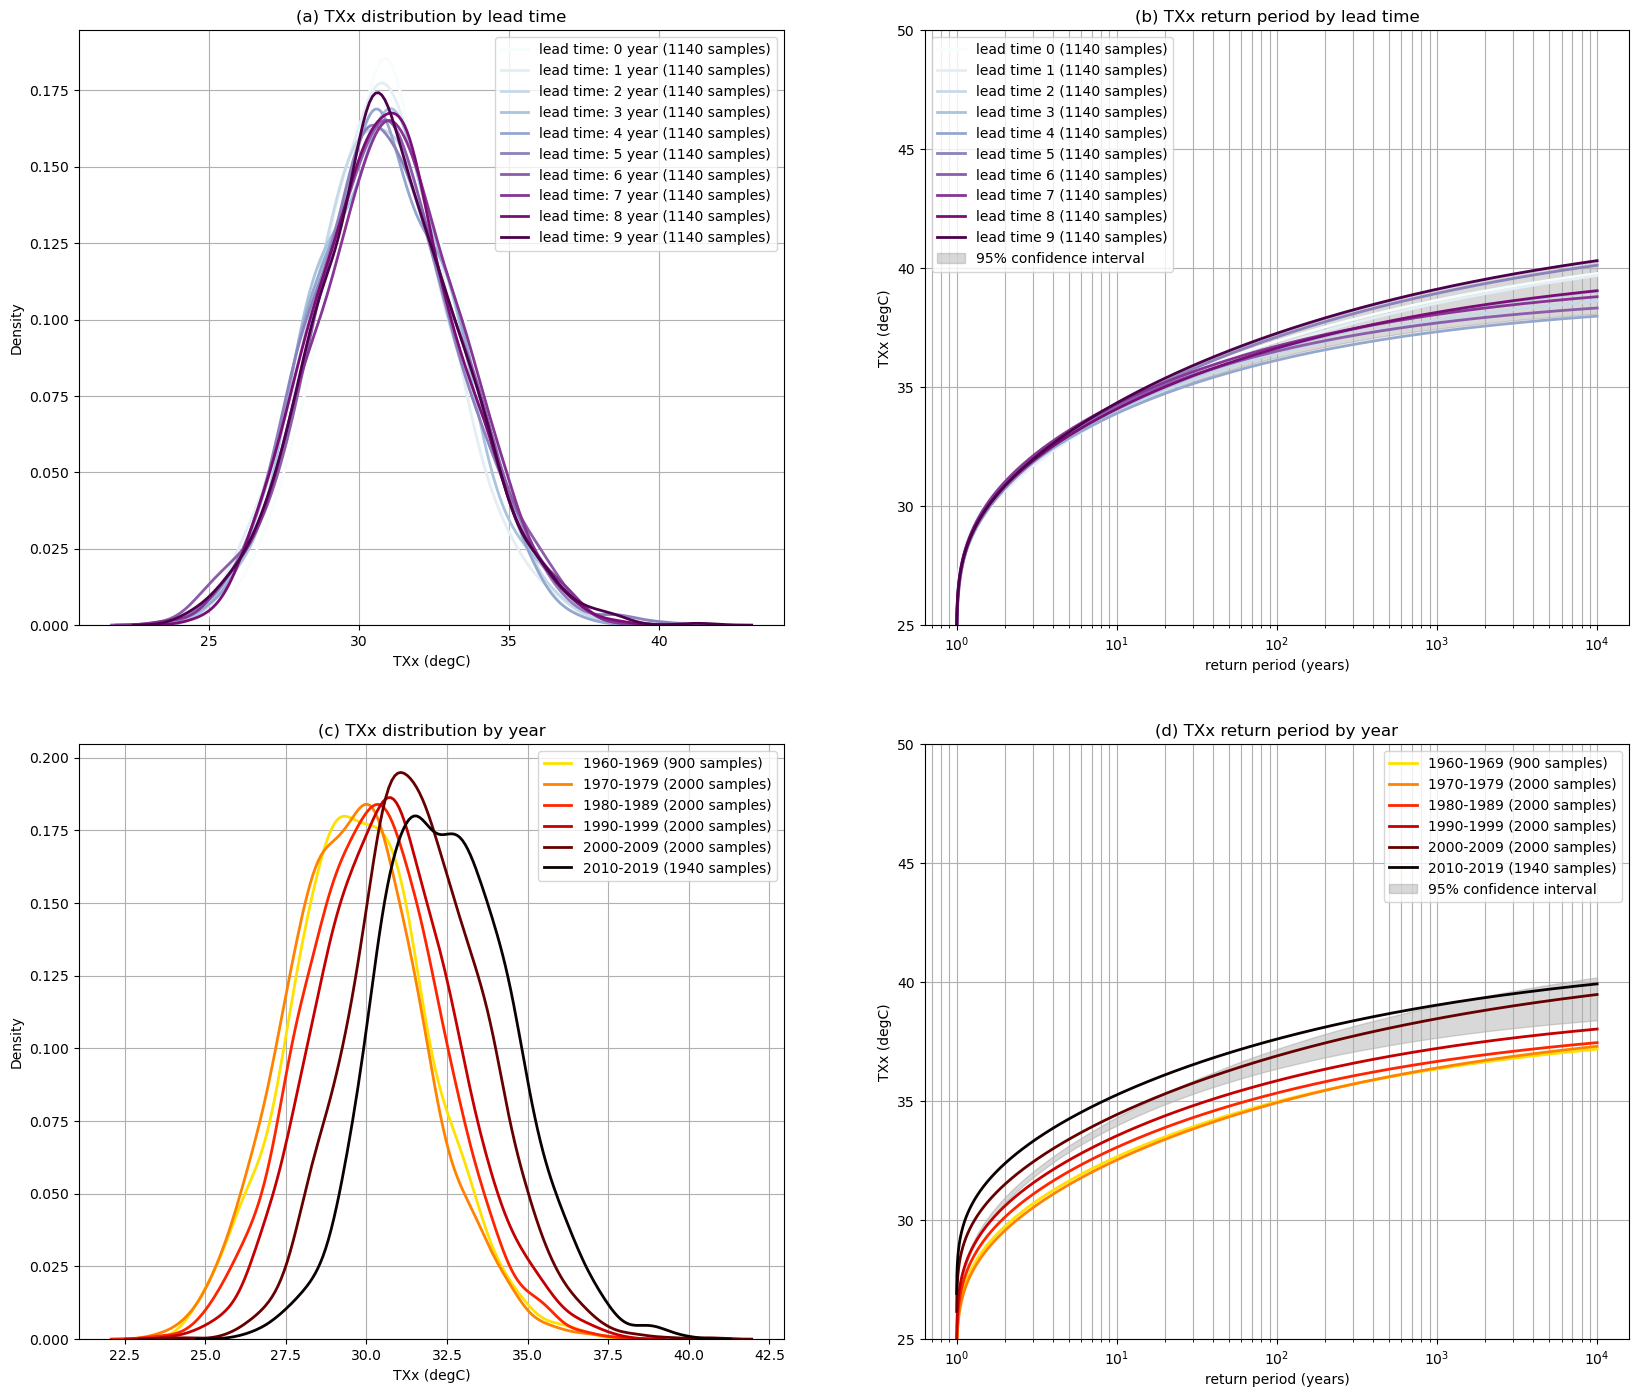

In [10]:
stability.create_plot(
    model_ds[var],
    'TXx',
    [1960, 1970, 1980, 1990, 2000, 2010],
    uncertainty=True,
    return_method='gev',
    units='TXx (degC)',
    ylim=(25, 50),
)

#### Independence

In [11]:
independence_ds = independence.run_tests(model_ds[var])

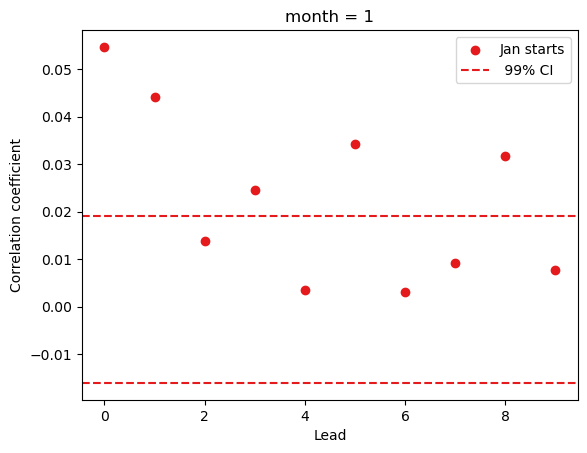

In [12]:
independence.point_plot(
    independence_ds,
    confidence_interval=0.99,
)

In [10]:
min_lead = 2

Drop lead times that aren't independent...

In [11]:
model_da_indep = model_ds[var].where(model_ds['lead_time'] >= min_lead)
model_da_indep = model_da_indep.dropna('lead_time')

In [12]:
model_da_indep_stacked = model_da_indep.stack({'sample': ['ensemble', 'init_date', 'lead_time']})

In [13]:
model_da_indep_baseline = time_utils.select_time_period(model_da_indep, baseline_period)
model_da_indep_baseline_stacked = model_da_indep_baseline.stack({'sample': ['ensemble', 'init_date', 'lead_time']})

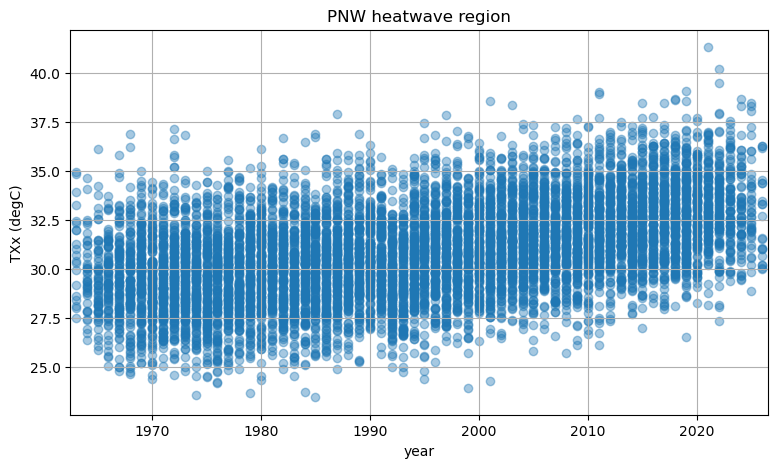

In [14]:
fig, ax = plt.subplots(figsize=[9, 5])
years = model_da_indep_stacked['time'].dt.year.values
unique_years = np.unique(model_da_indep_stacked.time.dt.year.values)

plt.scatter(
    years,
    model_da_indep_stacked.values,
    marker='o',
    color='tab:blue',
    alpha=0.4,
    label='raw data'
)
plt.xlim(unique_years[0] - 0.5, unique_years[-1] + 0.5)
plt.title('PNW heatwave region')
plt.ylabel('TXx (degC)')
plt.xlabel('year')
#plt.legend()
plt.grid()
plt.show()

#### Bias correction

In [15]:
correction_method = 'additive'

In [16]:
bias = bias_correction.get_bias(
    model_da_indep,
    obs_ds[var],
    correction_method,
    time_rounding='A',
    time_period=baseline_period
)
print(bias)

<xarray.DataArray 'tasmax' (month: 1)> Size: 8B
dask.array<subtract, shape=(1,), dtype=float64, chunksize=(1,), chunktype=numpy.ndarray>
Coordinates:
  * month    (month) int64 8B 1
Attributes:
    standard_name:           air_temperature
    long_name:               Daily Maximum Near-Surface Air Temperature
    comment:                 maximum near-surface (usually, 2 meter) air temp...
    units:                   °C
    original_name:           STMX
    cell_methods:            area: mean time: maximum
    cell_measures:           area: areacella
    history:                 2019-06-18T21:25:55Z altered by CMOR: Treated sc...
    units_metadata:          temperature: unknown
    climatological_period:   ['1970-01-01', '2018-12-30']
    bias_correction_method:  additive
    bias_correction_period:  1970-01-01-2018-12-30


In [17]:
bias.values

array([-0.0481839])

In [18]:
model_da_bc = bias_correction.remove_bias(model_da_indep, bias, correction_method)

In [19]:
model_da_bc = model_da_bc.compute()

In [20]:
model_da_bc_stacked = model_da_bc.stack({'sample': ['ensemble', 'init_date', 'lead_time']})

In [21]:
model_da_bc_baseline = time_utils.select_time_period(model_da_bc, baseline_period)
model_da_bc_baseline_stacked = model_da_bc_baseline.stack({'sample': ['ensemble', 'init_date', 'lead_time']})

#### Similarity testing

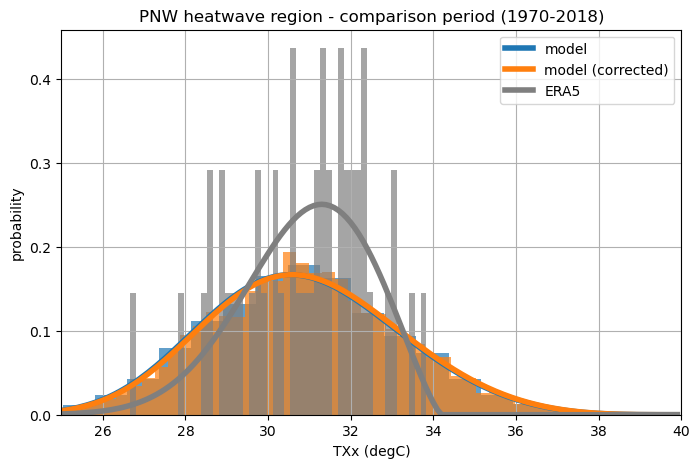

In [27]:
fig, ax = plt.subplots(figsize=[8, 5])
xvals = np.arange(25, 40, 0.1)

model_da_indep_baseline.plot.hist(bins=20, density=True, alpha=0.7, facecolor='tab:blue')
model_raw_shape, model_raw_loc, model_raw_scale = eva.fit_gev(model_da_indep_baseline_stacked.values)
model_raw_pdf = gev.pdf(xvals, model_raw_shape, model_raw_loc, model_raw_scale)
plt.plot(xvals, model_raw_pdf, color='tab:blue', linewidth=4.0, label='model')

model_da_bc_baseline.plot.hist(bins=50, density=True, alpha=0.7, facecolor='tab:orange')
model_bc_shape, model_bc_loc, model_bc_scale = eva.fit_gev(model_da_bc_baseline_stacked.values)
model_bc_pdf = gev.pdf(xvals, model_bc_shape, model_bc_loc, model_bc_scale)
plt.plot(xvals, model_bc_pdf, color='tab:orange', linewidth=4.0, label='model (corrected)')

obs_ds_baseline[var].plot.hist(ax=ax, bins=50, density=True, facecolor='tab:gray', alpha=0.7)
obs_shape, obs_loc, obs_scale = eva.fit_gev(obs_ds_baseline[var].values)
obs_pdf = gev.pdf(xvals, obs_shape, obs_loc, obs_scale)
plt.plot(xvals, obs_pdf, color='tab:gray', linewidth=4.0, label='ERA5')

plt.xlabel('TXx (degC)')
plt.ylabel('probability')
plt.title('PNW heatwave region - comparison period (1970-2018)')
plt.xlim(25, 40)
plt.legend()
plt.grid()
plt.show()

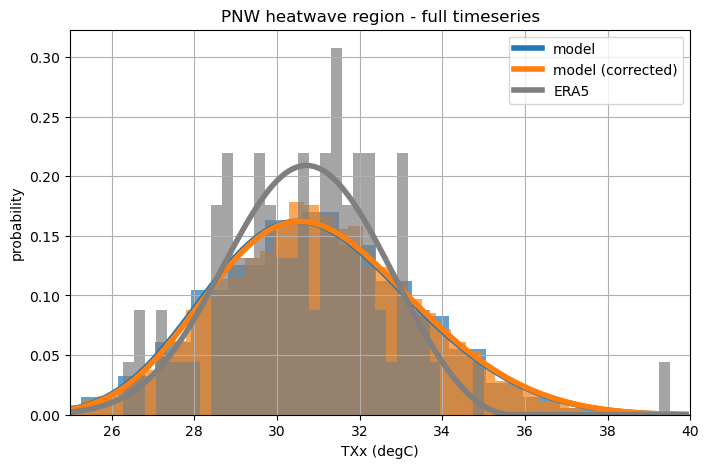

In [26]:
fig, ax = plt.subplots(figsize=[8, 5])
xvals = np.arange(25, 40, 0.1)

model_da_indep.plot.hist(bins=20, density=True, alpha=0.7, facecolor='tab:blue')
model_raw_shape, model_raw_loc, model_raw_scale = eva.fit_gev(model_da_indep_stacked.values)
model_raw_pdf = gev.pdf(xvals, model_raw_shape, model_raw_loc, model_raw_scale)
plt.plot(xvals, model_raw_pdf, color='tab:blue', linewidth=4.0, label='model')

model_da_bc.plot.hist(bins=50, density=True, alpha=0.7, facecolor='tab:orange')
model_bc_shape, model_bc_loc, model_bc_scale = eva.fit_gev(model_da_bc_stacked.values)
model_bc_pdf = gev.pdf(xvals, model_bc_shape, model_bc_loc, model_bc_scale)
plt.plot(xvals, model_bc_pdf, color='tab:orange', linewidth=4.0, label='model (corrected)')

obs_ds[var].plot.hist(ax=ax, bins=50, density=True, facecolor='tab:gray', alpha=0.7)
obs_shape, obs_loc, obs_scale = eva.fit_gev(obs_ds[var].values)
obs_pdf = gev.pdf(xvals, obs_shape, obs_loc, obs_scale)
plt.plot(xvals, obs_pdf, color='tab:gray', linewidth=4.0, label='ERA5')

plt.xlabel('TXx (degC)')
plt.ylabel('probability')
plt.title('PNW heatwave region - full timeseries')
plt.xlim(25, 40)
plt.legend()
plt.grid()
plt.show()

Since the data has a strong trend with time, the similarity testing is conducted over the time period equally sampled by the observations and model (1970-2018).

In [52]:
#moments.create_plot(
#    model_da_indep_baseline,
#    obs_ds_baseline[var],
#    da_bc_fcst=model_da_bc_baseline,
#)

In [28]:
similarity_ds = similarity.similarity_tests(model_da_indep_baseline, obs_ds_baseline[var])
print('KS score:', similarity_ds['ks_statistic'].values)
print('KS p-value:', similarity_ds['ks_pval'].values)
print('AD score:', similarity_ds['ad_statistic'].values)
print('AD p-value:', similarity_ds['ad_pval'].values)

KS score: 0.13320579
KS p-value: 0.33549625
AD score: 1.1517463
AD p-value: 0.10916975


p > 0.05 means that the null hypothesis (that the two samples are from the same population) cannot be rejected.

#### Process assessment

In [22]:
def ensemble_to_run(model_name, ensnum):
    """Map ensemble number to DCPP model run"""

    ensemble_to_run = {   
        'CanESM5': f'r{ensnum}i1p2f1',
        'CMCC-CM2-SR5': f'r{ensnum}i1p1f1',
        'EC-Earth3': f'r{ensnum}i1p1f1' if ensnum <= 10 else f'r{ensnum-5}i2p1f1',
        'HadGEM3-GC31-MM': f'r{ensnum}i1p1f2',
        'IPSL-CM6A-LR': f'r{ensnum}i1p1f1',
        'MIROC6': f'r{ensnum}i1p1f1',
        'MPI-ESM1-2-HR': f'r{ensnum}i1p1f1',
        'MRI-ESM2-0': f'r{ensnum}i1p1f1',
        'NorCPM1': f'r{ensnum}i1p1f1' if ensnum <= 10 else f'r{ensnum-10}i2p1f1'
    }
    run = ensemble_to_run[model_name]

    return run
    

def find_dcpp_data(event_df_row, model_name):
    """Find DCPP data for one row of a dataframe of events."""

    init_adjustment = {
        'CanESM5': -1,
        'CMCC-CM2-SR5': 0,
        'EC-Earth3': 0,
        'HadGEM3-GC31-MM': 0,
        'IPSL-CM6A-LR': -1,
        'MIROC6': 0,
        'MPI-ESM1-2-HR': 0,
        'MRI-ESM2-0': 0,
        'NorCPM1': 0,
    }

    assert model_name in init_adjustment
    
    init_date = int(event_df_row['init_date'].strftime('%Y')) + init_adjustment[model_name]
    ensemble = int(event_df_row['ensemble']) + 1
    run = ensemble_to_run(model_name, ensemble)
    txx_date = event_df_row['event_time']
    txx_value = round(float(event_df_row['tasmax']), 1)
    txx_summary = f'TXx of {txx_value} on {txx_date}: initialisation year {init_date}, ensemble member {run}'
    print(txx_summary)
    tasmax_files = glob.glob(f'/g/data/oi10/replicas/CMIP6/DCPP/*/{model_name}/dcppA-hindcast/s{init_date}-{run}/day/tasmax/*/*/*.nc')
    assert len(tasmax_files) == 1
    psl_files = glob.glob(f'/g/data/oi10/replicas/CMIP6/DCPP/*/{model_name}/dcppA-hindcast/s{init_date}-{run}/day/psl/*/*/*.nc')
    assert len(psl_files) == 1
        
    return tasmax_files[0], psl_files[0], txx_date, txx_value, txx_summary

In [23]:
def txx_check(da_tasmax, txx_value):
    """Check the spatial mean tasmax"""

    da_box = da_tasmax.sel(lat=slice(45, 52), lon=slice(237, 241))
    da_box_mean = spatial_selection.aggregate(da_box, 'weighted_mean')

    np.testing.assert_approx_equal(float(da_box_mean[-1]), txx_value, significant=1)
    

def get_start_date(event_date):
    """Get start date."""

    event_datetime = datetime.strptime(event_date, "%Y-%m-%d")
    start_datetime = event_datetime - timedelta(days=4)
    start_date = start_datetime.strftime("%Y-%m-%d")

    return start_date


def to_file_date(selected_date):
    """Convert a YYYY-MM-DD date to YYYYMMDD"""

    selected_datetime = datetime.strptime(selected_date, "%Y-%m-%d")
    selected_filedate = selected_datetime.strftime("%Y%m%d")

    return selected_filedate


def get_outfname(inpath, start_date, end_date):
    """Get output file name."""

    start_filedate = to_file_date(start_date)
    end_filedate = to_file_date(end_date)

    infname = inpath.split('/')[-1]
    fparts = infname.split('_')
    fparts[-1] = f'{start_filedate}-{end_filedate}.nc'
    fparts[-2] = fparts[-2] + '-NorthAmerica'
    outfname = '_'.join(fparts)

    return outfname


def get_event_data(event_df_row, model_name, write_to_file=False):
    """Plot a TXx event"""

    infile_tasmax, infile_psl, txx_date, txx_value, txx_summary = find_dcpp_data(event_df_row, model_name)

    start_date = get_start_date(txx_date)

    ds_tasmax = fileio.open_dataset(infile_tasmax)
    ds_tasmax = ds_tasmax.sel(
        time=slice(start_date, txx_date),
        lat=slice(25, 75),   #30-70N
        lon=slice(175, 305)   #60-180W
    )
    da_tasmax = general_utils.convert_units(ds_tasmax['tasmax'], 'degC')
    txx_check(da_tasmax, txx_value)
    
    ds_psl = fileio.open_dataset(infile_psl)
    ds_psl = ds_psl.sel(
        time=slice(start_date, txx_date),
        lat=slice(25, 75),   #30-70N
        lon=slice(175, 305)   #60-180W
    )
    da_psl = general_utils.convert_units(ds_psl['psl'], 'hPa')

    if write_to_file:
        output_ds_tasmax = da_tasmax.to_dataset()
        output_ds_tasmax.attrs = {
            'description': f'Five days leading up to and including this event - {txx_summary}',
            'model': model,
            'history': cmdprov.new_log(code_url=code_url),
        }
        fname_tasmax = get_outfname(infile_tasmax, start_date, txx_date)
        #output_ds_tasmax.to_netcdf(fname_tasmax)
        print(fname_tasmax)

        output_ds_psl = da_psl.to_dataset()
        output_ds_psl.attrs = {
            'description': f'Five days leading up to and including this event - {txx_summary}',
            'model': model,
            'history': cmdprov.new_log(code_url=code_url),
        }
        fname_psl = get_outfname(infile_psl, start_date, txx_date)
        #output_ds_psl.to_netcdf(fname_psl)
        print(fname_psl)

    return da_tasmax, da_psl

In [24]:
def plot_event(da_tasmax, da_psl):
    """Plot event."""

    fig = plt.figure(figsize=[15, 5])
    #map_proj = ccrs.PlateCarree(central_longitude=180)
    map_proj = ccrs.LambertConformal(
        central_longitude=240,
        central_latitude=50,
    )
    ax = fig.add_subplot(111, projection=map_proj)
    
    da_tasmax.isel(time=4).plot(
        ax=ax,
        transform=ccrs.PlateCarree(),
        cmap='hot_r',
        levels=np.arange(0, 51, 5),
        extend='both',
    #    cbar_kwargs={"label": label},
    )
    lines = da_psl.isel(time=4).plot.contour(
        ax=ax,
        transform=ccrs.PlateCarree(),
        levels=np.arange(900, 1100, 3),
        colors=["0.3"]
    )
    ax.clabel(lines, colors=["0.3"], manual=False, inline=True)
    
    ax.plot(
        [237, 237, 241, 241, 237],
        [52, 45, 45, 52, 52],
        transform=ccrs.PlateCarree(),
        color='green',
    )   
    ax.coastlines()
    #ax.set_extent([180, 300, 30, 70], crs=ccrs.PlateCarree(central_longitude=0))
    ax.add_feature(cartopy.feature.BORDERS)
    ax.gridlines(linestyle="--", draw_labels=True)
    
    plt.show()

In [25]:
model_da_bc_stacked_df = model_da_bc_stacked.to_dataframe()
model_da_bc_stacked_df_sorted = model_da_bc_stacked_df.sort_values(by=[var], ascending=False)
model_da_bc_stacked_df_sorted.head(n=5)

,,,event_time,time,ensemble,init_date,lead_time,tasmax
ensemble,init_date,lead_time,,,,,,
10,2012-01-01 00:00:00,9,2021-08-09,2021-01-01 00:00:00,10,2012-01-01 00:00:00,9,41.345381
8,2017-01-01 00:00:00,5,2022-07-19,2022-01-01 00:00:00,8,2017-01-01 00:00:00,5,40.229250
3,2017-01-01 00:00:00,5,2022-08-07,2022-01-01 00:00:00,3,2017-01-01 00:00:00,5,39.509400
2,2012-01-01 00:00:00,7,2019-07-28,2019-01-01 00:00:00,2,2012-01-01 00:00:00,7,39.106547
9,2008-01-01 00:00:00,3,2011-08-24,2011-01-01 00:00:00,9,2008-01-01 00:00:00,3,39.083057


TXx of 41.3 on 2021-08-09: initialisation year 2011, ensemble member r11i1p2f1
tasmax_day_CanESM5_dcppA-hindcast_s2011-r11i1p2f1_gn-NorthAmerica_20210805-20210809.nc
psl_day_CanESM5_dcppA-hindcast_s2011-r11i1p2f1_gn-NorthAmerica_20210805-20210809.nc


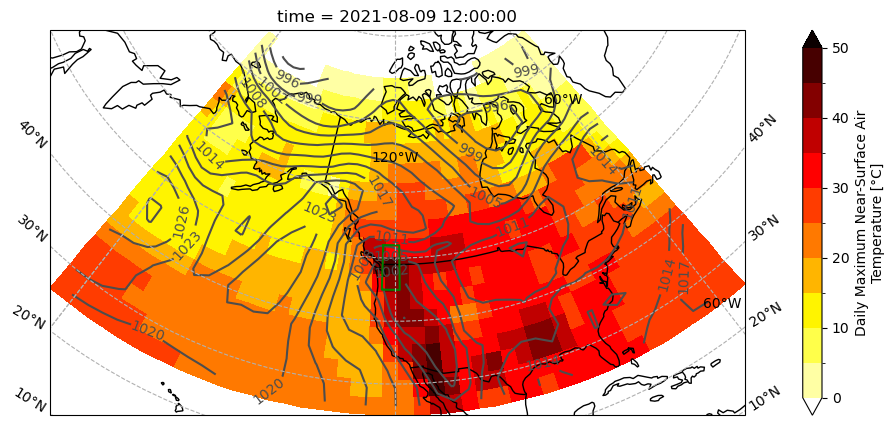

TXx of 40.2 on 2022-07-19: initialisation year 2016, ensemble member r9i1p2f1
tasmax_day_CanESM5_dcppA-hindcast_s2016-r9i1p2f1_gn-NorthAmerica_20220715-20220719.nc
psl_day_CanESM5_dcppA-hindcast_s2016-r9i1p2f1_gn-NorthAmerica_20220715-20220719.nc


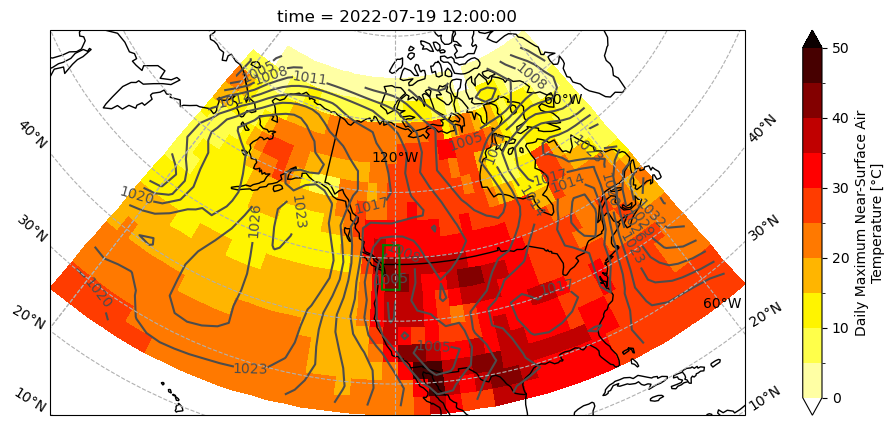

TXx of 39.5 on 2022-08-07: initialisation year 2016, ensemble member r4i1p2f1
tasmax_day_CanESM5_dcppA-hindcast_s2016-r4i1p2f1_gn-NorthAmerica_20220803-20220807.nc
psl_day_CanESM5_dcppA-hindcast_s2016-r4i1p2f1_gn-NorthAmerica_20220803-20220807.nc


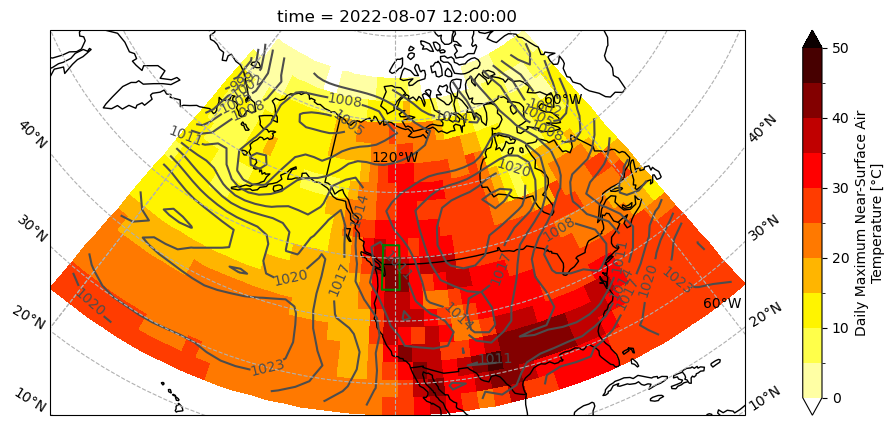

TXx of 39.1 on 2019-07-28: initialisation year 2011, ensemble member r3i1p2f1
tasmax_day_CanESM5_dcppA-hindcast_s2011-r3i1p2f1_gn-NorthAmerica_20190724-20190728.nc
psl_day_CanESM5_dcppA-hindcast_s2011-r3i1p2f1_gn-NorthAmerica_20190724-20190728.nc


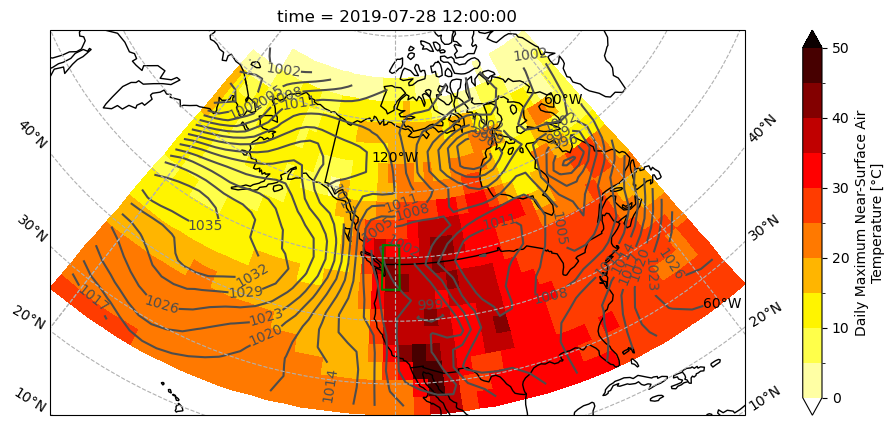

TXx of 39.1 on 2011-08-24: initialisation year 2007, ensemble member r10i1p2f1
tasmax_day_CanESM5_dcppA-hindcast_s2007-r10i1p2f1_gn-NorthAmerica_20110820-20110824.nc
psl_day_CanESM5_dcppA-hindcast_s2007-r10i1p2f1_gn-NorthAmerica_20110820-20110824.nc


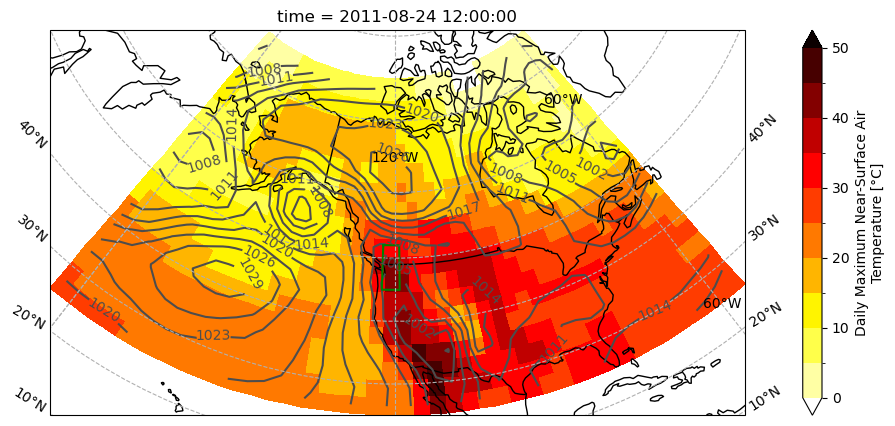

In [26]:
for event in range(5):
    da_tasmax, da_psl = get_event_data(
        model_da_bc_stacked_df_sorted.iloc[event],
        model,
        write_to_file=True
    )
    plot_event(da_tasmax, da_psl)

## Results

In [77]:
def write_samples(input_da, model, dtype):
    """Write samples to file."""

    assert dtype in ['bias corrected', 'raw']
    
    nsamples = len(input_da)
    numbers = list(np.arange(nsamples) + 1)
    output_da = xr.DataArray(
        data=np.round(input_da.values, 2),
        coords={'number': numbers,},
        name='TXx',
        attrs = {
            'long_name': 'hottest day of the year',
            'units': 'degC',
        }
    )
    output_ds = output_da.to_dataset()
    output_ds.attrs = {
        'description': f'{dtype} samples',
        'model': model,
        'history': cmdprov.new_log(code_url=code_url),
    }
    fname_dtype = dtype.replace(' ', '-')
    fname = f'txx_{model}_{fname_dtype}.nc'
    output_ds.to_netcdf(fname)
    print(fname)

In [78]:
write_samples(model_da_bc_stacked, model, 'bias corrected')

txx_CanESM5_bias-corrected.nc


In [79]:
write_samples(model_da_indep_stacked, model, 'raw')

txx_CanESM5_raw.nc


#### Non-stationary GEV

In [29]:
#AIC/BIC/LRT test to see if it's worth modelling the scale trend
daparams_list = [eva.fit_gev(
    model_da_bc_stacked,
    core_dim="sample",
    stationary=False,
    covariate=model_da_bc_stacked['time'].dt.year,
    use_basinhopping=True,
    scale1=scale1,
).values for scale1 in [0, None]]

data = model_da_bc_stacked.values
covariate = model_da_bc_stacked['time'].dt.year.values
nll_1 = eva._gev_nllf(daparams_list[0], data, covariate)
nll_2 = eva._gev_nllf(daparams_list[1], data, covariate)
result = eva.check_gev_relative_fit(data, nll_1, nll_2, test='bic', n_params=[4,5])
print('better to include the scale trend parameter:', result)

/home/599/dbi599/unseen-fork/unseen/eva.py:507: RuntimeWarning: invalid value encountered in log
  np.log(scale) + (1 + 1 / shape) * np.log(Z) + np.power(Z, -1 / shape),
/home/599/dbi599/unseen-fork/unseen/eva.py:507: RuntimeWarning: invalid value encountered in power
  np.log(scale) + (1 + 1 / shape) * np.log(Z) + np.power(Z, -1 / shape),
/home/599/dbi599/unseen-fork/unseen/eva.py:507: RuntimeWarning: divide by zero encountered in log
  np.log(scale) + (1 + 1 / shape) * np.log(Z) + np.power(Z, -1 / shape),
/home/599/dbi599/unseen-fork/unseen/eva.py:507: RuntimeWarning: overflow encountered in power
  np.log(scale) + (1 + 1 / shape) * np.log(Z) + np.power(Z, -1 / shape),
/home/599/dbi599/unseen-fork/unseen/eva.py:507: RuntimeWarning: invalid value encountered in log
  np.log(scale) + (1 + 1 / shape) * np.log(Z) + np.power(Z, -1 / shape),
/home/599/dbi599/unseen-fork/unseen/eva.py:507: RuntimeWarning: invalid value encountered in power
  np.log(scale) + (1 + 1 / shape) * np.log(Z) + np.

better to include the scale trend parameter: False


In [31]:
daparams = eva.fit_gev(
    model_da_bc_stacked,
    core_dim="sample",
    stationary=False,
    covariate=model_da_bc_stacked['time'].dt.year,
    use_basinhopping=True,
    scale1=None,
)

/home/599/dbi599/unseen-fork/unseen/eva.py:507: RuntimeWarning: invalid value encountered in log
  np.log(scale) + (1 + 1 / shape) * np.log(Z) + np.power(Z, -1 / shape),
/home/599/dbi599/unseen-fork/unseen/eva.py:507: RuntimeWarning: invalid value encountered in power
  np.log(scale) + (1 + 1 / shape) * np.log(Z) + np.power(Z, -1 / shape),
/home/599/dbi599/unseen-fork/unseen/eva.py:507: RuntimeWarning: divide by zero encountered in log
  np.log(scale) + (1 + 1 / shape) * np.log(Z) + np.power(Z, -1 / shape),


In [32]:
for param, value in zip(daparams.dparams.values, daparams.values):
    print(param, value)

c 0.20915855438752226
location_0 -109.08943616909143
location_1 0.06982080804626789
scale_0 2.0352227478258
scale_1 0.0


In [33]:
return_period = float(eva.get_return_period(obs_max_event, daparams, covariate=2021).values)

In [34]:
print(f'The return period of a {obs_max_event:.2f}C event in 2021 is {return_period:.0f} years.')

The return period of a 39.51C event in 2021 is 1136 years.


In [35]:
for year in np.arange(1960, 2030):
    rp = float(eva.get_return_period(obs_max_event, daparams, covariate=year).values)
    print(f'The return period of a {obs_max_event:.2f}C event in {year} is {rp:.0f} years.')

The return period of a 39.51C event in 1960 is inf years.
The return period of a 39.51C event in 1961 is inf years.
The return period of a 39.51C event in 1962 is inf years.
The return period of a 39.51C event in 1963 is inf years.
The return period of a 39.51C event in 1964 is inf years.
The return period of a 39.51C event in 1965 is inf years.
The return period of a 39.51C event in 1966 is inf years.
The return period of a 39.51C event in 1967 is inf years.
The return period of a 39.51C event in 1968 is inf years.
The return period of a 39.51C event in 1969 is inf years.
The return period of a 39.51C event in 1970 is inf years.
The return period of a 39.51C event in 1971 is inf years.
The return period of a 39.51C event in 1972 is inf years.
The return period of a 39.51C event in 1973 is inf years.
The return period of a 39.51C event in 1974 is inf years.
The return period of a 39.51C event in 1975 is inf years.
The return period of a 39.51C event in 1976 is inf years.
The return per